# Support Vector Machine (SVM)

## Importing the libraries

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn import datasets
%pylab inline
pylab.rcParams['figure.figsize'] = (10, 6)


Populating the interactive namespace from numpy and matplotlib


## Importing the dataset

In [7]:
from sklearn.datasets import load_wine

wine = load_wine()
X = wine.data[:, [0, 9]]  # For example: 'alcohol' and 'color_intensity'
y = wine.target


In [8]:
from sklearn.datasets import load_wine

# Load Wine dataset
wine = load_wine()
X = wine.data        # shape: (178, 13)
y = wine.target      # shape: (178,)



In [9]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=0)

print('There are {} samples in the training set and {} samples in the test set'.format(
    X_train.shape[0], X_test.shape[0]))


There are 124 samples in the training set and 54 samples in the test set


## Exploratory Data Analysis
###  Place the cifar data into a pandas dataframe

In [10]:
wine_df = pd.DataFrame(X[:5], columns=wine.feature_names)
print(wine_df.head())

print('\nThe unique labels in this data are', np.unique(y))

   alcohol  malic_acid   ash  alcalinity_of_ash  magnesium  total_phenols  \
0    14.23        1.71  2.43               15.6      127.0           2.80   
1    13.20        1.78  2.14               11.2      100.0           2.65   
2    13.16        2.36  2.67               18.6      101.0           2.80   
3    14.37        1.95  2.50               16.8      113.0           3.85   
4    13.24        2.59  2.87               21.0      118.0           2.80   

   flavanoids  nonflavanoid_phenols  proanthocyanins  color_intensity   hue  \
0        3.06                  0.28             2.29             5.64  1.04   
1        2.76                  0.26             1.28             4.38  1.05   
2        3.24                  0.30             2.81             5.68  1.03   
3        3.49                  0.24             2.18             7.80  0.86   
4        2.69                  0.39             1.82             4.32  1.04   

   od280/od315_of_diluted_wines  proline  
0                  

## Splitting the dataset into the Training set and Test set

In [11]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=.3, random_state=0)

print('There are {} samples in the training set and {} samples in the test set'.format(
X_train.shape[0], X_test.shape[0]))


There are 124 samples in the training set and 54 samples in the test set


## Feature Scaling

In [12]:
from sklearn.preprocessing import StandardScaler
import pandas as pd
from tensorflow.keras.datasets import cifar10

sc = StandardScaler()

sc.fit(X_train)

X_train_std = sc.transform(X_train)
X_test_std = sc.transform(X_test)

column_names = [f'pixel_{i}' for i in range(X_train_std.shape[1])]
df = pd.DataFrame(X_train_std[:5], columns=column_names)



print('After standardizing our features, the first 5 rows of our data now look like this:\n')
print(df)


After standardizing our features, the first 5 rows of our data now look like this:

    pixel_0   pixel_1   pixel_2   pixel_3   pixel_4   pixel_5   pixel_6  \
0  0.910831 -0.462599 -0.011426 -0.820679  0.062417  0.588204  0.935654   
1 -0.956099 -0.966087 -1.537254 -0.147487 -0.554019  0.169986  0.072432   
2  0.359522  1.675016 -0.374718  0.133010  1.363782 -1.118128 -1.314889   
3  0.221695  1.047864 -0.774340  0.413506  0.130910 -1.268687 -1.458759   
4  1.098777 -0.771758  1.114780  1.535493 -0.964977  1.156982  0.915101   

    pixel_7   pixel_8   pixel_9  pixel_10  pixel_11  pixel_12  
0 -0.761914  0.130072 -0.512387  0.657066  1.943545  0.937010  
1  0.207913  0.784626 -0.982107 -0.408595  0.581180 -1.413367  
2  0.531189 -0.440566  2.220529 -1.559509 -1.448466  0.286837  
3  0.531189 -0.524483 -0.426984 -1.516883 -1.281645  0.270582  
4 -1.246827  0.432174 -0.691735  1.722727  0.775804 -1.094782  


## Plot the original Data

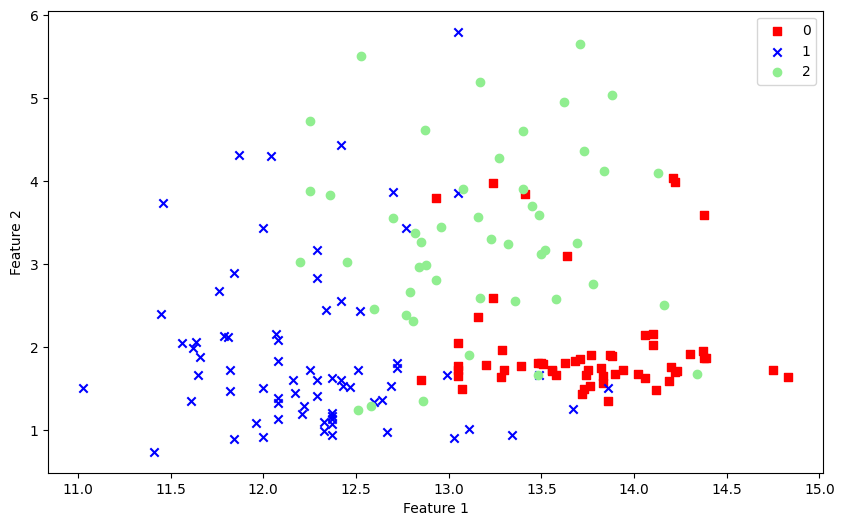

In [13]:
from matplotlib.colors import ListedColormap
import matplotlib.pyplot as plt

markers = ('s', 'x', 'o', '^', 'v', '>', '<', 'p', '*', '+')
colors = ('red', 'blue', 'lightgreen', 'cyan', 'magenta', 'yellow', 'black', 'orange', 'purple', 'brown')

for idx, cl in enumerate(np.unique(y)):
    plt.scatter(x=X[y == cl, 0], y=X[y == cl, 1],
                color=colors[idx], marker=markers[idx], label=cl)

plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend(loc='best')
plt.show()


### If we plot the original data, we can see that one of the classes is linearly separable, but the other two are not.

## Training the SVM model on the Training set

In [14]:
from sklearn.svm import SVC

svm = SVC(kernel='rbf', random_state=0, gamma=.10, C=1.0)
svm.fit(X_train_std, y_train)


SVC(gamma=0.1, random_state=0)

### Dispplay the support Vectors of model

In [15]:
print("Support Vector for model are :",svm.support_vectors_)

Support Vector for model are : [[ 3.97111623e-01 -5.86262625e-01 -8.10669074e-01 -7.08480088e-01
  -4.17033456e-01  2.36900695e-01  2.26579186e-01 -7.61913800e-01
  -4.40565584e-01 -4.48334679e-01  2.73427991e-01  2.33637960e-01
   1.74972671e+00]
 [ 3.21933239e-01  1.41002216e+00 -2.65730701e-01 -5.68231794e-01
   1.99402752e-01  6.38390712e-01  6.78743062e-01 -3.57819227e-01
   7.97213914e-02 -2.73257213e-01 -5.79100822e-01  5.53376666e-01
  -2.17047803e-01]
 [ 8.38683579e-02 -5.77429506e-01 -1.17396132e+00 -1.99876438e+00
  -5.54019280e-01  7.72220717e-01  1.33643597e+00 -1.57010295e+00
   2.17765275e+00  9.39474500e-01  6.99692398e-01  4.28261520e-01
   1.31085967e+00]
 [ 2.21392256e+00 -5.77429506e-01  9.75615474e-02 -2.27926097e+00
  -6.22512192e-01  1.40791324e+00  1.76804695e+00  5.31188834e-01
   2.00981824e+00  1.70841724e-01  1.25383613e+00  1.78031229e-01
   1.31085967e+00]
 [-1.66726254e-01 -6.92260047e-01  5.69841471e-01 -4.84082818e-01
  -3.48540544e-01  3.70730701e-01  

In [16]:
print("Number of suppoort Vectors of each class 0 : - ",svm.n_support_[0])
print("Number of suppoort Vectors of each class 1 : - ",svm.n_support_[1])
print("Number of suppoort Vectors of each class 2 : - ",svm.n_support_[2])

Number of suppoort Vectors of each class 0 : -  17
Number of suppoort Vectors of each class 1 : -  29
Number of suppoort Vectors of each class 2 : -  21


In [18]:
print("Indices for support vectors are : ",svm.support_)

Indices for support vectors are :  [  7  18  29  39  41  43  44  49  60  70  80  81  93 106 110 116 117   4
   8  11  13  15  16  17  20  21  24  33  34  35  45  47  51  53  55  67
  72  74  91  98 100 101 104 105 107 114   2   3   9  22  23  28  30  40
  56  58  59  63  75  79  82  84  92  94  95 109 112]


## Finding Accuracy of model on Test and Train Set

In [19]:
print('The accuracy of the svm classifier on training data is {:.2f} out of 1'.format(svm.score(X_train_std, y_train)))

print('The accuracy of the svm classifier on test data is {:.2f} out of 1'.format(svm.score(X_test_std, y_test)))

The accuracy of the svm classifier on training data is 0.99 out of 1
The accuracy of the svm classifier on test data is 1.00 out of 1


## Finding Accuracy of model on using confiusion matrix

In [21]:
from sklearn import metrics

confusion_matrix = metrics.confusion_matrix(y_test, svm.predict(X_test_std))
print(confusion_matrix)


[[19  0  0]
 [ 0 22  0]
 [ 0  0 13]]


In [23]:
from sklearn import metrics

y_pred = svm.predict(X_test_std)

# Accuracy
accuracy = metrics.accuracy_score(y_test, y_pred)

# Precision (macro average)
precision = metrics.precision_score(y_test, y_pred, average='macro')

# Recall/Sensitivity (macro average)
recall = metrics.recall_score(y_test, y_pred, average='macro')

# F1 Score (macro average)
f1 = metrics.f1_score(y_test, y_pred, average='macro')

print(f"Accuracy: {accuracy:.3f}")
print(f"Precision (macro): {precision:.3f}")
print(f"Recall/Sensitivity (macro): {recall:.3f}")
print(f"F1 Score (macro): {f1:.3f}")


Accuracy: 1.000
Precision (macro): 1.000
Recall/Sensitivity (macro): 1.000
F1 Score (macro): 1.000


In [24]:
#metrics
print({"Accuracy":Accuracy,
       "Precision":Precision,
       "Sensitivity_recall":Sensitivity_recall,
       "Specificity":Specificity,
       "F1_score":F1_score},end = "")

{'Accuracy': 1.0, 'Precision': 1.0, 'Sensitivity_recall': 1.0, 'Specificity': 1.0, 'F1_score': 1.0}

## Create the function for Visualizing Testing and Training model

In [25]:
def versiontuple(v):
    return tuple(map(int, (v.split("."))))


def plot_decision_regions(X, y, classifier, test_idx=None, resolution=0.02):

    # setup marker generator and color map
    markers = ('s', 'x', 'o', '^', 'v')
    colors = ('red', 'blue', 'lightgreen', 'gray', 'cyan')
    cmap = ListedColormap(colors[:len(np.unique(y))])

    # plot the decision surface
    x1_min, x1_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    x2_min, x2_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx1, xx2 = np.meshgrid(np.arange(x1_min, x1_max, resolution),
                           np.arange(x2_min, x2_max, resolution))
    Z = classifier.predict(np.array([xx1.ravel(), xx2.ravel()]).T)
    Z = Z.reshape(xx1.shape)
    plt.contourf(xx1, xx2, Z, alpha=0.4, cmap=cmap)
    plt.xlim(xx1.min(), xx1.max())
    plt.ylim(xx2.min(), xx2.max())

    for idx, cl in enumerate(np.unique(y)):
        plt.scatter(x=X[y == cl, 0], y=X[y == cl, 1],
                    alpha=0.8, c=cmap(idx),
                    marker=markers[idx], label=cl)
plt.show()


## Visualising the Train set results

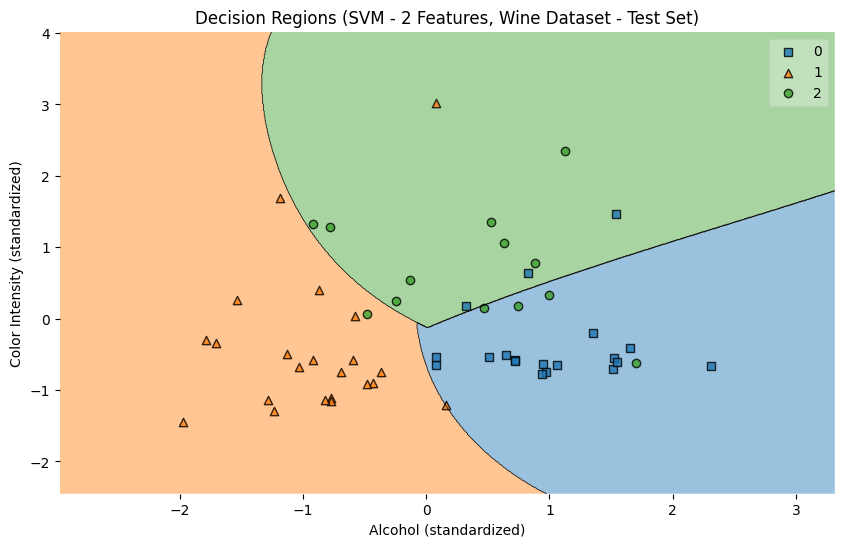

In [41]:
# Selecting the first two features for visualization
X_test_std_2d = X_test_std[:, [0, 1]]
y_test_2d = y_test  # Assuming the target values remain the same

# Train an SVM model on the 2-dimensional training data
# First, select the first two features of the training data
X_train_std_2d = X_train_std[:, [0, 1]]

# Create and train the SVM model
from sklearn.svm import SVC
svm_2d = SVC(kernel='rbf', random_state=0, gamma=.10, C=1.0)
svm_2d.fit(X_train_std_2d, y_train)

# Now call the plotting function with the defined variables
plot_decision_regions(X_test_std_2d, y_test_2d, svm_2d)
plt.xlabel('Alcohol (standardized)')
plt.ylabel('Color Intensity (standardized)')
plt.title('Decision Regions (SVM - 2 Features, Wine Dataset - Test Set)')
plt.show()